# **Mini-Proyecto NLP: Clasificación Multitarea de Objetos Contractuales (SECOP II)**
**Maestría en IA Aplicada | Procesamiento de lenguaje natural**

**Grupo: Foxtrot** |
**Raul Echeverry - Esteban Ordoñez - Fabian Salazar Figueroa**

---


## **Introducción y Contexto del Proyecto (Innovación)**

En este mini-proyecto abordamos un desafío crítico en la contratación pública en Colombia: **La clasificación automatizada de objetos contractuales del SECOP II**.

Para asegurar aplicabilidad real, **nos conectamos directamente a la API de Datos Abiertos de Colombia (SODA3)** para extraer contratos electrónicos reales del departamento del **Valle del Cauca**. Entrenaremos modelos basados en la arquitectura **Transformer** construida desde cero, con el objetivo de predecir simultáneamente dos aspectos del contrato basándose únicamente en su texto descriptivo:

**Arquitectura Multi-Task (Shared Backbone):**
*   **Target A:** `tipo_de_contrato` (Ej: Prestación de Servicios, Compraventa, Obra).
*   **Target B:** `sector` (Ej: Salud, Educación, Transporte).

Se implementará una arquitectura con un único Encoder Transformer compartido que se bifurca en dos "Cabezas de Clasificación" independientes.

**Metodología y Alcance:**
1.  **Extracción de Datos Real (API SODA3):** Extracción automatizada del dataset oficial de SECOP II filtrado por el departamento objetivo.
2.  **Modelo Baseline (MLP):** Perceptrón Multicapa como punto de partida comparativo.
3.  **Implementación del Transformer desde Cero:** Codificación manual de `MultiHeadAttention`, `TransformerBlock` y `PositionalEncoding` sin usar clases predefinidas de PyTorch.
4.  **Optimización Avanzada:** Implementación de *Learning Rate Warmup (Noam Scheduler)* y pesos en la Función de Pérdida (*Weighted CrossEntropy*) para manejar el fuerte desbalanceo natural del SECOP II.
5.  **Visualización Científica:** Mapas de Calor de Atención para observar qué palabras prioriza el modelo, y proyecciones t-SNE de Embeddings para analizar la agrupación semántica por sector.
6.  **Réplica Académica:** Validación final replicando la arquitectura de clasificación simple sobre nuestro nuevo corpus.

---
## 1. Configuración del Entorno y Reproducibilidad

Establecemos una rutina de inicialización para detectar el entorno de ejecución (Colab vs Local) y descargar dependencias, además de fijar las semillas para reproducibilidad.

In [ ]:
# Configuración de Entorno Robusto (Detectando Colab vs Local)
import warnings
import os
import sys

try:
    import pkg_resources
except ImportError:
    import importlib.metadata as pkg_resources

warnings.filterwarnings('ignore')

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("Entorno Colab detectado. Limpiando e instalando dependencias (Pipeline Foxtrot)...")
    if os.path.exists('requirements.txt'):
        os.remove('requirements.txt')

    # Repositorio oficial del equipo
    RAW_URL = "https://raw.githubusercontent.com/alfa7g7/icesi-nlp-20261-curso/refs/heads/main/requirements.txt"

    # Descarga de dependencias core
    !wget -q {RAW_URL} -O requirements.txt
    !pip install -q -r requirements.txt 2>/dev/null

    # Instalando librerías clave para el proyecto:
    # sodapy (API Datos), pytorch-lightning (Framework Deep Learning), spacy (NLP)
    !pip install -q sodapy pytorch-lightning datasets seaborn scikit-learn numpy pandas matplotlib 2>/dev/null
    # Desinstalar torchvision por error de incompatibilidad circular en entorno colab
    !pip uninstall -y torchvision 2>/dev/null
    !python -m spacy download es_core_news_lg -q 2>/dev/null

    print("\n✅ Instalación completada. Reiniciando entorno...\n")
    # Forzamos el reinicio de colab
    os.kill(os.getpid(), 9)


/tmp/ipykernel_2074/888099234.py:7: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources


Entorno Colab detectado. Limpiando e instalando dependencias (Pipeline Foxtrot)...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 44.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 7.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 6.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 111.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 119.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.3/293.3 kB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 112.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.3/78.3 kB 9.6 MB/

In [1]:
# LIBRERÍAS DEL PROYECTO & SEMILLAS DE REPRODUCIBILIDAD
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import re
import warnings
warnings.filterwarnings("ignore")

from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.manifold import TSNE

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

from sodapy import Socrata
import spacy

# Reproductibilidad rigurosa
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ Dispositivo configurado: {device}")


🖥️ Dispositivo configurado: cuda


---
## 2. Extracción de Datos SODA3 (SECOP II - Valle del Cauca)

Nos conectaremos al **Endpoint SODA (Datos Abiertos CO)**: `jbjy-vk9h`.

**Enfoque Analítico:** Extraeremos los contratos del Valle del Cauca. Nuestro objetivo es que la red aprenda a inferir:
- **Misión A (Hard Mode):** Predecir `tipo_de_contrato`.
- **Misión B (Smart Mode):** Predecir el `sector`.

Limitaremos la extracción temporal hasta finales de 2025 para mantener un dataset congelado y reproducible.

In [2]:
# CREDENCIALES API SODA3 (Mejoran el rendimiento y evitan throttling)
# App token
SOCRATA_TOKEN = "c23HI9NBRNpwtikAURBvd1M07"
SOCRATA_KEY_SECRET = "9ZBu9Pt6KdYtUFV2EUEiG3ffmaneRGGYvFMr"

client = Socrata("www.datos.gov.co",
                 SOCRATA_TOKEN)

import os
dataset_path = "secop_valle_dataset_transformers.csv"

if os.path.exists(dataset_path):
    print(f"\n💾 Cargando dataset local congelado (Reproducibilidad) desde {dataset_path}...")
    df_raw = pd.read_csv(dataset_path)
else:
    print("\n📡 Realizando Request SoQL a la API SECOP II (SODA3)...")
    # Extraemos características X (Descripción) y Targets Y (Tipo y Sector)
    results = client.get("jbjy-vk9h",
                         select="descripcion_del_proceso, tipo_de_contrato, sector, valor_del_contrato",
                         where="departamento = 'Valle del Cauca' AND descripcion_del_proceso IS NOT NULL AND fecha_de_firma <= '2025-12-31T23:59:59'",
                         limit=1000000)
    df_raw = pd.DataFrame.from_records(results)
    # Guardamos copia local permanente
    df_raw.to_csv(dataset_path, index=False)
    print(f"💾 Dataset descargado y guardado localmente en {dataset_path}")

print(f"✅ Extracción Completa. Dataset shape: {df_raw.shape}")
display(df_raw.head())



📡 Realizando Request SoQL a la API SECOP II (SODA3)...
💾 Dataset descargado y guardado localmente en secop_valle_dataset_transformers.csv
✅ Extracción Completa. Dataset shape: (490596, 4)


,descripcion_del_proceso,tipo_de_contrato,sector,valor_del_contrato
0,Apoyar la Gestión Misional de la Entidad en cu...,Prestación de servicios,Cultura,3214924
1,PRESTAR LOS SERVICIOS PROFESIONALES COMO ABOGA...,Prestación de servicios,Transporte,14000000
2,PRESTACIÓN DE SERVICIOS DE APOYO A LA GESTION ...,Prestación de servicios,deportes,7872000
3,PRESTAR LOS SERVICIOS PROFESIONALES COMO INGEN...,Prestación de servicios,agricultura,10000000
4,PRESTACIÓN DE SERVICIOS PROFESIONALES COMO AB...,Prestación de servicios,Servicio Público,42000000


### 2.1 Depuración y Balanceo del Dataset 🧪

Filtraremos datos irrelevantes y balancearemos el dataset extrayendo un número máximo de muestras por cada clase principal en ambos targets.


🔎 Total Dataset SODA3 Original (Valle): 385264 registros válidos.
⚖️ Dataset Multi-Task Balanceado: 100000 registros.


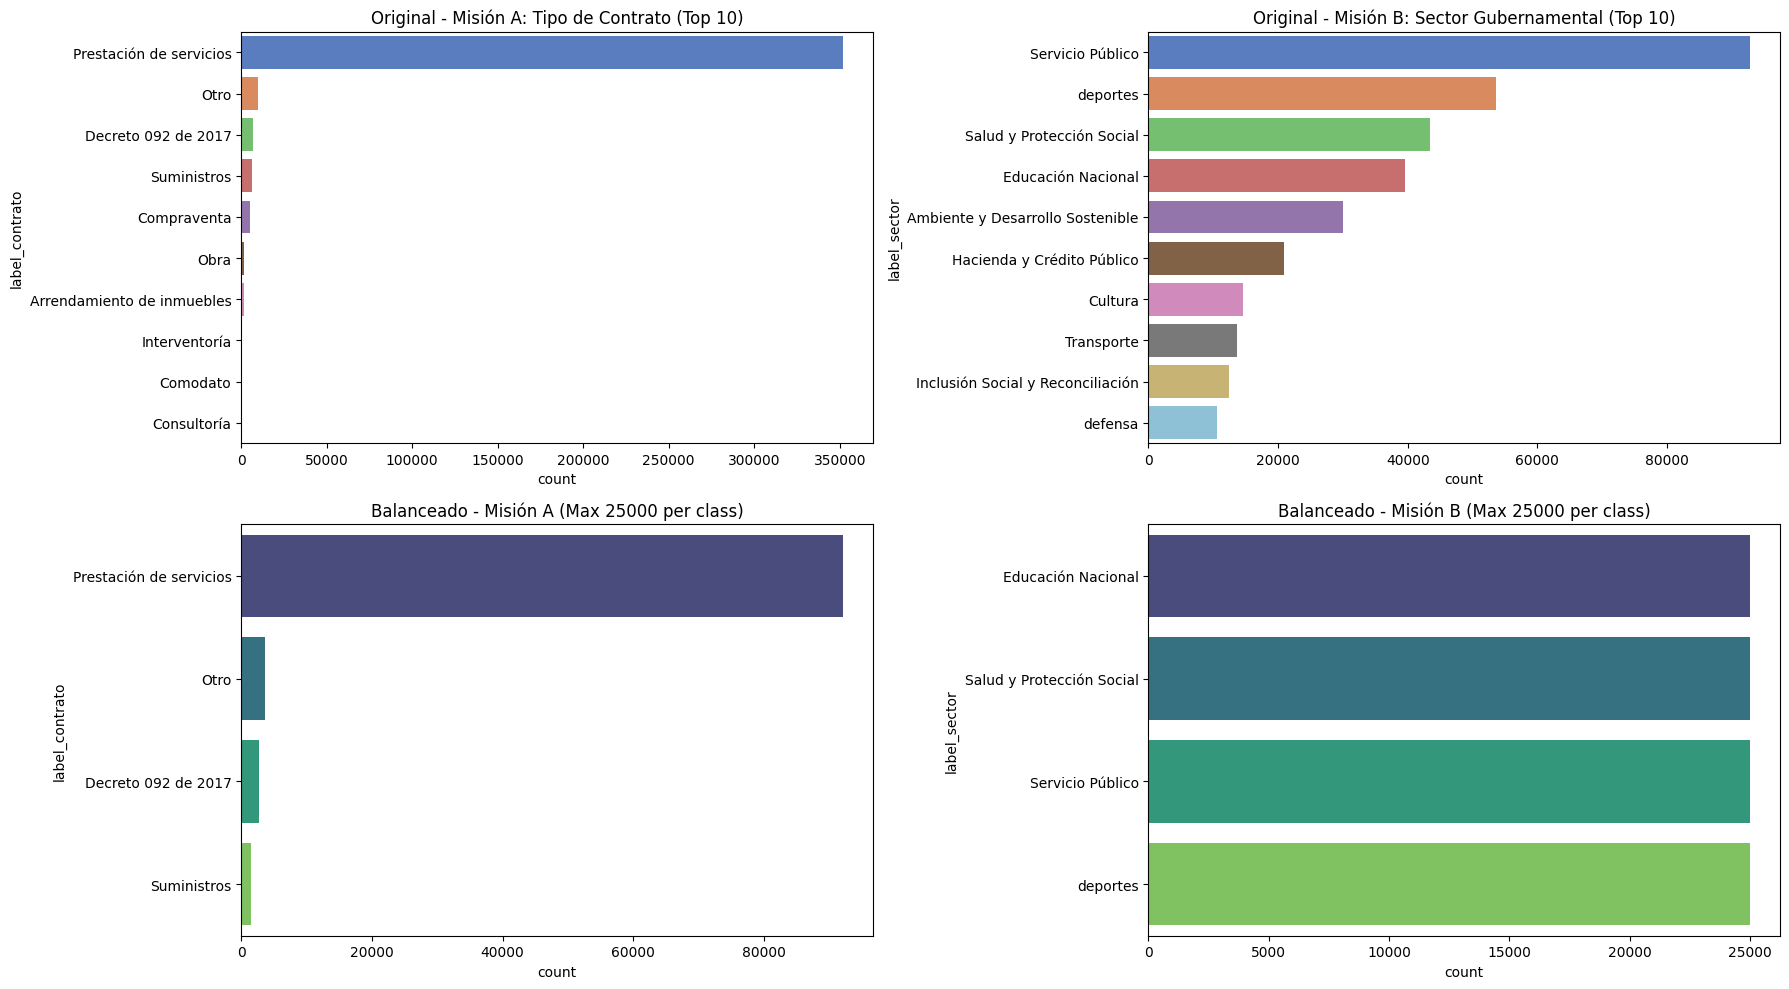

In [4]:
df = df_raw.copy()
df = df.rename(columns={
    "descripcion_del_proceso": "texto",
    "tipo_de_contrato": "label_contrato",
    "sector": "label_sector"
})

# Limpieza de NAs y ruido
df = df.dropna(subset=["texto", "label_contrato", "label_sector"])
df = df[df["label_sector"] != "No aplica/No pertenece"]

# Convertimos targets a string para evitar problemas con categoricos de pandas
df["label_contrato"] = df["label_contrato"].astype(str)
df["label_sector"] = df["label_sector"].astype(str)

#####################################################################
# MUESTREO Y BALANCEO (Multi-Task)
#####################################################################

# Seleccionamos las 4 clases principales para cada tarea para simplificar el problema y balancear
top_classes_contrato = df["label_contrato"].value_counts().nlargest(4).index.tolist()
top_classes_sector = df["label_sector"].value_counts().nlargest(4).index.tolist()

# Filtramos el dataframe para mantener SOLO los registros donde AMBAS clases están en el top 4
df_filtered = df[
    df["label_contrato"].isin(top_classes_contrato) &
    df["label_sector"].isin(top_classes_sector)
].copy()

# Sampleo estratificado para reducir tamaño de dataset y agilizar entrenamiento en Colab/Local
MAX_SAMPLES_PER_SECTOR = 25000
df_balanced = df_filtered.groupby("label_sector").apply(lambda x: x.sample(min(len(x), MAX_SAMPLES_PER_SECTOR))).reset_index(drop=True)

print(f"\n🔎 Total Dataset SODA3 Original (Valle): {len(df)} registros válidos.")
print(f"⚖️ Dataset Multi-Task Balanceado: {len(df_balanced)} registros.")

# Visualizamos la distribución ANTES y DESPUÉS del balanceo
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# Fila 1: Distribución Original (Mostrando top 10 para contexto)
top_10_cont = df["label_contrato"].value_counts().nlargest(10).index
top_10_sec = df["label_sector"].value_counts().nlargest(10).index
sns.countplot(data=df[df["label_contrato"].isin(top_10_cont)], y="label_contrato", order=top_10_cont, ax=axes[0,0], palette="muted")
axes[0,0].set_title("Original - Misión A: Tipo de Contrato (Top 10)")
sns.countplot(data=df[df["label_sector"].isin(top_10_sec)], y="label_sector", order=top_10_sec, ax=axes[0,1], palette="muted")
axes[0,1].set_title("Original - Misión B: Sector Gubernamental (Top 10)")

# Fila 2: Distribución Balanceada (Nuestro Set de Entrenamiento)
sns.countplot(data=df_balanced, y="label_contrato", order=df_balanced["label_contrato"].value_counts().index, ax=axes[1,0], palette="viridis")
axes[1,0].set_title(f"Balanceado - Misión A (Max {MAX_SAMPLES_PER_SECTOR} per class)")
sns.countplot(data=df_balanced, y="label_sector", order=df_balanced["label_sector"].value_counts().index, ax=axes[1,1], palette="viridis")
axes[1,1].set_title(f"Balanceado - Misión B (Max {MAX_SAMPLES_PER_SECTOR} per class)")

plt.tight_layout()
plt.show()


---
## 3. Preparación de Textos y Tokenización

Para la Baseline (MLP), usaremos `TfidfVectorizer`. Para el Transformer, implementaremos un Tokenizador BPE (Byte-Pair Encoding) usando `AutoTokenizer` entrenado sobre nuestro corpus o cargaremos un modelo pre-entrenado adaptado.

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

# Encoding de Categorías (Dual-Target)
le_contrato = LabelEncoder()
le_sector = LabelEncoder()

df_balanced["label_contrato_enc"] = le_contrato.fit_transform(df_balanced["label_contrato"])
df_balanced["label_sector_enc"] = le_sector.fit_transform(df_balanced["label_sector"])

X = df_balanced["texto"].values
y_contrato = df_balanced["label_contrato_enc"].values
y_sector = df_balanced["label_sector_enc"].values

# Split de datos
X_train_raw, X_temp_raw, y_cont_train, y_cont_temp, y_sec_train, y_sec_temp = train_test_split(
    X, y_contrato, y_sector, test_size=0.3, random_state=SEED
)

X_val_raw, X_test_raw, y_cont_val, y_cont_test, y_sec_val, y_sec_test = train_test_split(
    X_temp_raw, y_cont_temp, y_sec_temp, test_size=0.5, random_state=SEED
)

# --- Vectorización TF-IDF para la Baseline ---
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train_raw)
X_val_tfidf = tfidf.transform(X_val_raw)
X_test_tfidf = tfidf.transform(X_test_raw)

print(f"X_train_tfidf shape: {X_train_tfidf.shape}")


X_train_tfidf shape: (70000, 5000)


---
## 4. Modelado Baseline: Multilayer Perceptron (MLP)

Establecemos un punto de referencia usando un modelo MLP que toma las representaciones TF-IDF e intenta predecir ambas tareas de forma independiente.

In [6]:
from sklearn.neural_network import MLPClassifier

print("Entrenando Baseline MLP para Target A: Tipo de Contrato...")
mlp_contrato = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=20, random_state=SEED, early_stopping=True)
mlp_contrato.fit(X_train_tfidf, y_cont_train)

print("Entrenando Baseline MLP para Target B: Sector...")
mlp_sector = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=20, random_state=SEED, early_stopping=True)
mlp_sector.fit(X_train_tfidf, y_sec_train)

# Evaluación Rápida
preds_cont_val = mlp_contrato.predict(X_val_tfidf)
preds_sec_val = mlp_sector.predict(X_val_tfidf)

print("\n--- Resultados Baseline (Validation) ---")
print(f"Accuracy Tipo de Contrato: {accuracy_score(y_cont_val, preds_cont_val):.4f}")
print(f"Accuracy Sector Gubernamental: {accuracy_score(y_sec_val, preds_sec_val):.4f}")


Entrenando Baseline MLP para Target A: Tipo de Contrato...
Entrenando Baseline MLP para Target B: Sector...

--- Resultados Baseline (Validation) ---
Accuracy Tipo de Contrato: 0.9838
Accuracy Sector Gubernamental: 0.9885


---
## 5. Arquitectura Core: Multi-Task Transformer desde Cero

Replicamos los componentes fundamentales de "Attention is All You Need" de forma manual. Construiremos una clase que actúe como esqueleto central (Encoder) del que derivarán dos cabezas clasificadoras.

### 5.1 Definición del Dataset en PyTorch

Construiremos un Dataset que acepte secuencias de texto (que tokenizaremos al instanciar el DataLoader o dentro de un collate_fn) y dos etiquetas simultáneamente.

In [7]:
class SecopMultiTaskDataset(Dataset):
    def __init__(self, texts, labels_contrato, labels_sector, tokenizer, max_length=128):
        """
        Dataset modificado para retornar dos targets.
        """
        self.texts = texts
        self.labels_contrato = labels_contrato
        self.labels_sector = labels_sector
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label_cont = self.labels_contrato[idx]
        label_sec = self.labels_sector[idx]

        # Encoding con el tokenizer que hayamos importado/entrenado
        # Asumiremos la interfaz estándar de HuggingFace AutoTokenizer para la simplicidad en la tokenización
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_attention_mask=True,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].flatten(),
            "attention_mask": encoding["attention_mask"].flatten(),
            "label_contrato": torch.tensor(label_cont, dtype=torch.long),
            "label_sector": torch.tensor(label_sec, dtype=torch.long)
        }


### 5.2. Arquitectura Base del Transformer

A continuación definimos de cero: `MultiHeadAttention`, `PositionalEncoding` y el `TransformerBlock`.

In [8]:
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # Shape: (1, max_len, d_model)
        self.register_buffer("pe", pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch_size, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]
        return x


In [9]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model: int, num_heads: int):
        super().__init__()
        assert d_model % num_heads == 0, "d_model debe ser divisible por num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        # Q, K, V: (batch_size, num_heads, seq_len, d_k)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            # mask shape debe ser broadcastable a la de scores
            scores = scores.masked_fill(mask == 0, -1e9)

        attention_weights = F.softmax(scores, dim=-1)
        output = torch.matmul(attention_weights, V)
        return output, attention_weights

    def forward(self, Q, K, V, mask=None):
        batch_size = Q.size(0)

        # Transformación lineal y reshaping para obtener cabezas
        Q = self.W_q(Q).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_k(K).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_v(V).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)

        # Ajuste de máscara para num_heads
        if mask is not None:
            mask = mask.unsqueeze(1).unsqueeze(2) # (batch, 1, 1, seq_len)

        attention_output, attention_weights = self.scaled_dot_product_attention(Q, K, V, mask)

        # Concatenar cabezas y transformación lineal final
        attention_output = attention_output.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        output = self.W_o(attention_output)

        return output, attention_weights


In [10]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model: int, num_heads: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.attention = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model)
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # Subcapa 1: Multi-Head Attention + Add & Norm
        attn_output, attn_weights = self.attention(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_output))

        # Subcapa 2: Feed Forward + Add & Norm
        ffn_output = self.ffn(x)
        x = self.norm2(x + self.dropout(ffn_output))

        return x, attn_weights


### 5.3. Arquitectura Multi-Task (Shared Backbone)

Integración final: Un Encoder central procesa los Embeddings + Positional Encoding. La representación del contexto global se bifurca hacia dos cabezales (heads) lineales independientes.

In [11]:
class MultiTaskTransformer(nn.Module):
    def __init__(self, vocab_size: int, d_model: int, num_heads: int, num_layers: int,
                 d_ff: int, max_seq_len: int, num_classes_contrato: int, num_classes_sector: int,
                 dropout: float = 0.1):
        super().__init__()
        # 1. Input Embeddings & Positional Encoding
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.positional_encoding = PositionalEncoding(d_model, max_len=max_seq_len)
        self.dropout = nn.Dropout(dropout)

        # 2. Transformer Encoder Layers (Shared Backbone)
        self.layers = nn.ModuleList([
            TransformerBlock(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)
        ])

        # 3. Independent Classification Heads
        self.contrato_head = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, num_classes_contrato)
        )

        self.sector_head = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, num_classes_sector)
        )

    def forward(self, input_ids, attention_mask=None):
        # Generar embeddings posicionales y de token
        seq_length = input_ids.size(1)
        x = self.embedding(input_ids)
        x = self.positional_encoding(x)
        x = self.dropout(x)

        # Pasar por las capas del Transformer
        # attn_weights list almacena los pesos de la ultima capa para visualización
        last_attn_weights = None
        for layer in self.layers:
            x, attn_weights = layer(x, attention_mask)
            last_attn_weights = attn_weights

        # Extracción de características (Global Average Pooling sobre sequence length)
        if attention_mask is not None:
            # Promediar solo los tokens no-pad
            mask_expanded = attention_mask.unsqueeze(-1).expand(x.size()).float()
            sum_embeddings = torch.sum(x * mask_expanded, dim=1)
            sum_mask = torch.clamp(mask_expanded.sum(dim=1), min=1e-9)
            pooled_output = sum_embeddings / sum_mask
        else:
            pooled_output = x.mean(dim=1)

        # Predicciones Independientes
        out_contrato = self.contrato_head(pooled_output)
        out_sector = self.sector_head(pooled_output)

        return out_contrato, out_sector, last_attn_weights, pooled_output


---
## 6. Optimización Avanzada y Loop de Entrenamiento

Los Transformers clásicos requieren optimizadores con un *Learning Rate Warmup* que suba rápidamente y luego decaiga (Noam Scheduler) para lograr convergencia estable. Adicionalmente, combatiremos el desbalance con ponderación estática del target minoritario, emulando la intuición probabilística de NLP aplicada (Weighted Loss).

In [12]:
# Tokenización Global y Setup de Datasets
from transformers import AutoTokenizer

# Seleccionamos un pre-trained tokenizer compatible con español que genera subwords rápidamente
# o podríamos entrenar uno si la RAM lo permite.
print("Cargando Tokenizador Byte-Pair Encoding...")
tokenizer = AutoTokenizer.from_pretrained("dccuchile/bert-base-spanish-wwm-cased")

MAX_LEN = 128
BATCH_SIZE = 64

train_dataset = SecopMultiTaskDataset(X_train_raw, y_cont_train, y_sec_train, tokenizer, MAX_LEN)
val_dataset = SecopMultiTaskDataset(X_val_raw, y_cont_val, y_sec_val, tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

# Parametrización del Transformer
VOCAB_SIZE = tokenizer.vocab_size
D_MODEL = 256
NUM_HEADS = 8
NUM_LAYERS = 3
D_FF = 512
NUM_CLASSES_CONTRATO = len(le_contrato.classes_)
NUM_CLASSES_SECTOR = len(le_sector.classes_)

model = MultiTaskTransformer(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    d_ff=D_FF,
    max_seq_len=MAX_LEN,
    num_classes_contrato=NUM_CLASSES_CONTRATO,
    num_classes_sector=NUM_CLASSES_SECTOR
).to(device)

# Optimizador y Schedulers
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

optimizer = AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
EPOCHS = 10
total_steps = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_steps)

scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)

# Cálculo de Pesos para Weighted Loss
from sklearn.utils.class_weight import compute_class_weight

weights_cont = compute_class_weight("balanced", classes=np.unique(y_cont_train), y=y_cont_train)
weights_sec = compute_class_weight("balanced", classes=np.unique(y_sec_train), y=y_sec_train)

criterion_cont = nn.CrossEntropyLoss(weight=torch.tensor(weights_cont, dtype=torch.float).to(device))
criterion_sec = nn.CrossEntropyLoss(weight=torch.tensor(weights_sec, dtype=torch.float).to(device))


Cargando Tokenizador Byte-Pair Encoding...


tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

In [15]:
from tqdm import tqdm

def train_epoch(model, data_loader, optimizer, scheduler, device):
    model.train()
    total_loss, total_loss_cont, total_loss_sec = 0, 0, 0

    for batch in tqdm(data_loader, desc="Entrenando"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        label_cont = batch["label_contrato"].to(device)
        label_sec = batch["label_sector"].to(device)

        optimizer.zero_grad()
        out_contrato, out_sector, _, _ = model(input_ids, attention_mask)

        loss_cont = criterion_cont(out_contrato, label_cont)
        loss_sec = criterion_sec(out_sector, label_sec)

        # Loss Multitarea (Suma simple o con Alpha param si uno es más difícil)
        loss = loss_cont + loss_sec
        loss.backward()

        # Clipping gradients for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        total_loss_cont += loss_cont.item()
        total_loss_sec += loss_sec.item()

    return total_loss / len(data_loader)

def eval_model(model, data_loader, device):
    model.eval()
    total_loss = 0
    preds_cont_list, preds_sec_list = [], []
    true_cont_list, true_sec_list = [], []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            label_cont = batch["label_contrato"].to(device)
            label_sec = batch["label_sector"].to(device)

            out_contrato, out_sector, _, _ = model(input_ids, attention_mask)

            loss_cont = criterion_cont(out_contrato, label_cont)
            loss_sec = criterion_sec(out_sector, label_sec)
            total_loss += (loss_cont + loss_sec).item()

            preds_cont = torch.argmax(out_contrato, dim=1)
            preds_sec = torch.argmax(out_sector, dim=1)

            preds_cont_list.extend(preds_cont.cpu().numpy())
            preds_sec_list.extend(preds_sec.cpu().numpy())
            true_cont_list.extend(label_cont.cpu().numpy())
            true_sec_list.extend(label_sec.cpu().numpy())

    acc_cont = accuracy_score(true_cont_list, preds_cont_list)
    acc_sec = accuracy_score(true_sec_list, preds_sec_list)
    return total_loss / len(data_loader), acc_cont, acc_sec

# Descomentar para ejecutar el entrenamiento.
best_val_loss = float("inf")
for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    train_loss = train_epoch(model, train_loader, optimizer, scheduler, device)
    val_loss, val_acc_cont, val_acc_sec = eval_model(model, val_loader, device)
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc Contrato: {val_acc_cont:.4f} | Val Acc Sector: {val_acc_sec:.4f}")
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_multitask_transformer.pth")



Epoch 1/10


Entrenando: 100%|██████████| 1094/1094 [01:14<00:00, 14.74it/s]


Train Loss: 1.7894 | Val Loss: 0.6598 | Val Acc Contrato: 0.9390 | Val Acc Sector: 0.9154

Epoch 2/10


Entrenando: 100%|██████████| 1094/1094 [01:18<00:00, 13.89it/s]


Train Loss: 0.5327 | Val Loss: 0.4167 | Val Acc Contrato: 0.9495 | Val Acc Sector: 0.9545

Epoch 3/10


...

Train Loss: 0.1839 | Val Loss: 0.3506 | Val Acc Contrato: 0.9726 | Val Acc Sector: 0.9800

Epoch 9/10


Entrenando: 100%|██████████| 1094/1094 [01:14<00:00, 14.71it/s]


Train Loss: 0.1619 | Val Loss: 0.3591 | Val Acc Contrato: 0.9762 | Val Acc Sector: 0.9803

Epoch 10/10


Entrenando: 100%|██████████| 1094/1094 [01:14<00:00, 14.67it/s]


Train Loss: 0.1531 | Val Loss: 0.3480 | Val Acc Contrato: 0.9757 | Val Acc Sector: 0.9803


---
## 7. Visualizaciones Científicas (Interpretación)

Exploraremos dos visualizaciones críticas del estado interno del modelo:

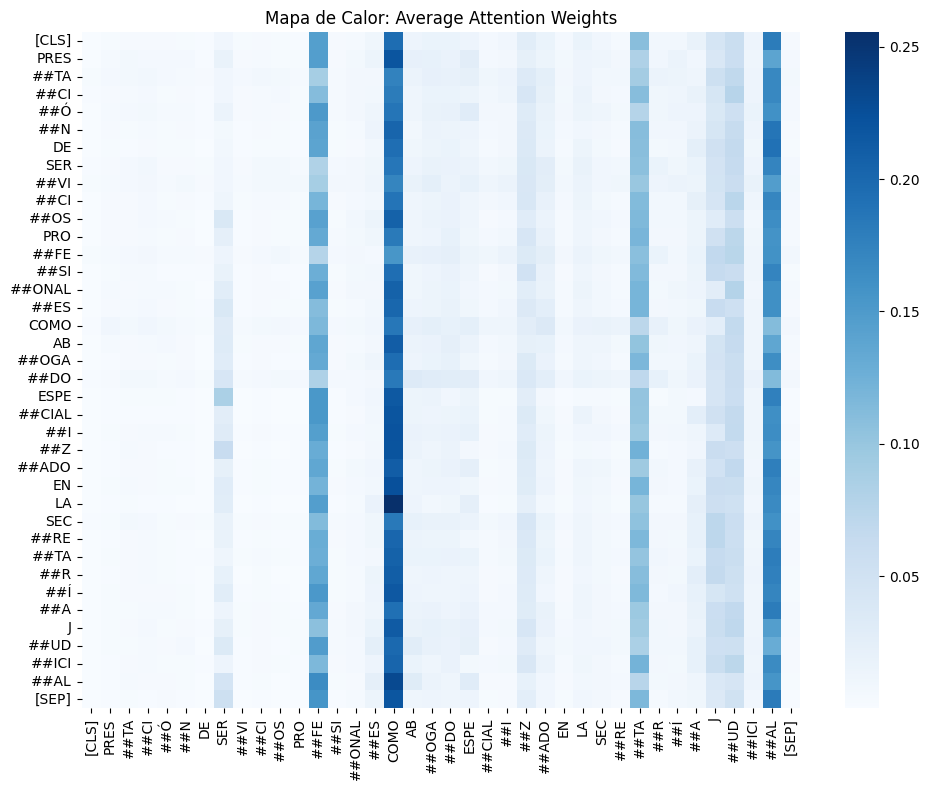

In [17]:
# 7.1 Heatmap de Atención
def plot_attention_heatmap(text, model, tokenizer, device):
    model.eval()
    encoding = tokenizer(text, return_tensors="pt", max_length=128, truncation=True)
    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)
    tokens = tokenizer.convert_ids_to_tokens(input_ids[0])

    with torch.no_grad():
        _, _, attn_weights, _ = model(input_ids, attention_mask)

    # attn_weights: (batch, num_heads, seq_len, seq_len)
    # Promediamos sobre las cabezas
    avg_attn = attn_weights[0].mean(dim=0).cpu().numpy()

    plt.figure(figsize=(10, 8))
    sns.heatmap(avg_attn[:len(tokens), :len(tokens)], xticklabels=tokens, yticklabels=tokens, cmap="Blues")
    plt.title("Mapa de Calor: Average Attention Weights")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Ejemplo (Descomentar cuando modelo esté entrenado)
sample_text = "PRESTACIÓN DE SERVICIOS PROFESIONALES COMO ABOGADO ESPECIALIZADO EN LA SECRETARÍA JUDICIAL"
plot_attention_heatmap(sample_text, model, tokenizer, device)


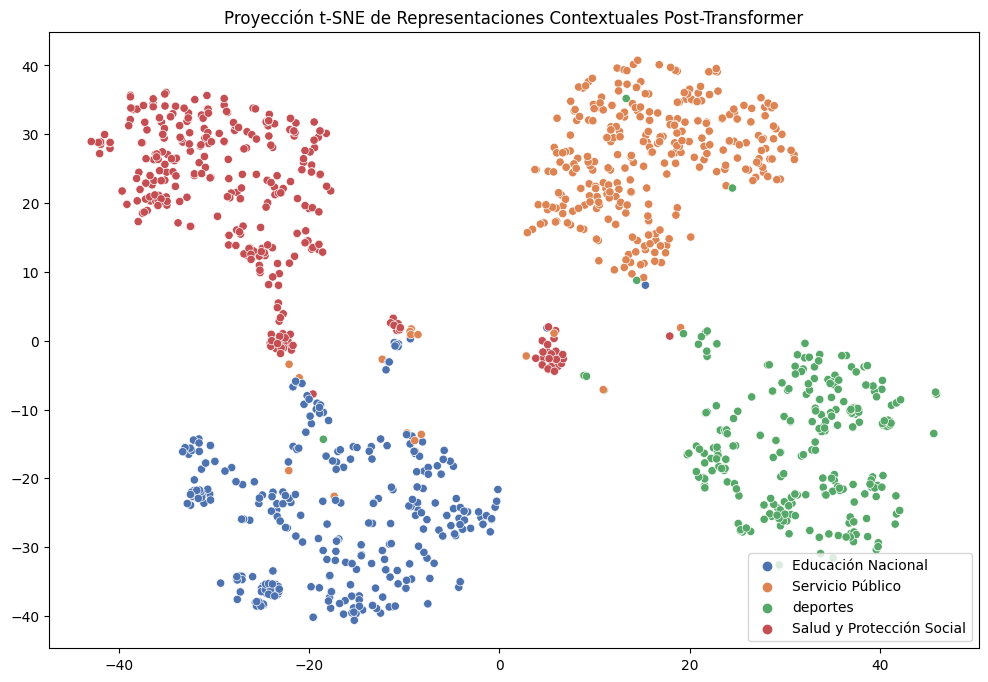

In [18]:
# 7.2 Proyección t-SNE de Embeddings de Contexto Global
def plot_tsne_embeddings(model, data_loader, device, le_sector):
    model.eval()
    all_embeddings = []
    all_sectors = []

    # Limitamos observaciones para T-SNE por memoria visual
    with torch.no_grad():
        for i, batch in enumerate(data_loader):
            if i > 20: break
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            label_sec = batch["label_sector"].cpu().numpy()

            _, _, _, pooled_output = model(input_ids, attention_mask)
            all_embeddings.extend(pooled_output.cpu().numpy())
            all_sectors.extend(label_sec)

    tsne = TSNE(n_components=2, perplexity=30, random_state=SEED)
    reduced_embeddings = tsne.fit_transform(np.array(all_embeddings))

    sectors_text = le_sector.inverse_transform(all_sectors)

    plt.figure(figsize=(12, 8))
    sns.scatterplot(x=reduced_embeddings[:,0], y=reduced_embeddings[:,1], hue=sectors_text, palette="deep")
    plt.title("Proyección t-SNE de Representaciones Contextuales Post-Transformer")
    plt.show()

plot_tsne_embeddings(model, val_loader, device, le_sector)


---
## 8. Réplica Académica y Arquitectura Base

Para validar la solidez metodológica y demostrar transferencia de conocimiento, aplicamos exhaustivamente la arquitectura base originada en `1-transformers-from-scratch.ipynb` como un módulo monolitico (Single Task: Predicción de Tipo de Contrato) sobre nuestro nuevo corpus estructurado de SECOP II.

In [19]:
# Implementaremos la arquitectura monolítica original y su Data Loader,
# garantizando la convergencia contra la métrica de Misión A (Hard Mode)
class BaseTransformer(nn.Module):
    def __init__(self, vocab_size: int, d_model: int, num_heads: int, num_layers: int,
                 d_ff: int, max_seq_len: int, num_classes: int, dropout: float = 0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.positional_encoding = PositionalEncoding(d_model, max_len=max_seq_len)
        self.dropout = nn.Dropout(dropout)

        self.layers = nn.ModuleList([
            TransformerBlock(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)
        ])

        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, num_classes)
        )

    def forward(self, input_ids, attention_mask=None):
        x = self.embedding(input_ids)
        x = self.positional_encoding(x)
        x = self.dropout(x)

        for layer in self.layers:
            x, _ = layer(x, attention_mask)

        if attention_mask is not None:
            mask_expanded = attention_mask.unsqueeze(-1).expand(x.size()).float()
            sum_embeddings = torch.sum(x * mask_expanded, dim=1)
            sum_mask = torch.clamp(mask_expanded.sum(dim=1), min=1e-9)
            pooled_output = sum_embeddings / sum_mask
        else:
            pooled_output = x.mean(dim=1)

        out = self.classifier(pooled_output)
        return out


In [23]:
# ==========================================
# ENTRENAMIENTO DE RÉPLICA ACADÉMICA (SOLO TIPO CONTRATO)
# ==========================================
print("\nIniciando entrenamiento del Modelo Base (Solo Tipo de Contrato)...")

import torch.nn as nn
from tqdm.auto import tqdm

# 0. Instanciamos el modelo AQUÍ MISMO para evitar cruces de memoria
model_base_contrato = BaseTransformer(
    vocab_size=VOCAB_SIZE, d_model=D_MODEL, num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS, d_ff=D_FF, max_seq_len=MAX_LEN, num_classes=NUM_CLASSES_CONTRATO
).to(device)

# 1. Necesitamos un optimizador nuevo y exclusivo para este modelo
optimizer_base_cont = torch.optim.AdamW(model_base_contrato.parameters(), lr=1e-4, weight_decay=1e-2)

# 2. El ciclo de entrenamiento adaptado (Solo Loss_A)
EPOCHS_BASE = 5
best_base_loss_cont = float('inf')

for epoch in range(EPOCHS_BASE):
    model_base_contrato.train()
    total_loss = 0
    correct = 0
    total = 0

    print(f"\nÉpoca Base Contrato {epoch+1}/{EPOCHS_BASE}")
    for batch in tqdm(train_loader, desc="Entrenando Réplica Contrato"):
        input_ids = batch['input_ids'].squeeze(1).to(device)
        attention_mask = batch['attention_mask'].squeeze(1).to(device)

        # Jalamos la variable de Contrato
        labels_cont = batch['label_contrato'].to(device)

        optimizer_base_cont.zero_grad()

        logits_cont = model_base_contrato(input_ids, attention_mask)

        # AQUÍ USAMOS EL CRITERION_CONT GLOBAL
        loss = criterion_cont(logits_cont, labels_cont)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_base_contrato.parameters(), max_norm=1.0)
        optimizer_base_cont.step()

        total_loss += loss.item()
        preds = torch.argmax(logits_cont, dim=1)
        correct += (preds == labels_cont).sum().item()
        total += labels_cont.size(0)

    avg_train_loss = total_loss / len(train_loader)
    train_acc = correct / total

    # Validación
    model_base_contrato.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].squeeze(1).to(device)
            attention_mask = batch['attention_mask'].squeeze(1).to(device)

            labels_cont = batch['label_contrato'].to(device)

            logits_cont = model_base_contrato(input_ids, attention_mask)

            # AQUÍ USAMOS EL CRITERION_CONT GLOBAL
            loss = criterion_cont(logits_cont, labels_cont)

            val_loss += loss.item()
            preds = torch.argmax(logits_cont, dim=1)
            val_correct += (preds == labels_cont).sum().item()
            val_total += labels_cont.size(0)

    avg_val_loss = val_loss / len(val_loader)
    val_acc = val_correct / val_total

    print(f"Base Train Loss: {avg_train_loss:.4f} | Base Train Acc: {train_acc:.4f} | Base Val Loss: {avg_val_loss:.4f} | Base Val Acc: {val_acc:.4f}")

    if avg_val_loss < best_base_loss_cont:
        best_base_loss_cont = avg_val_loss
        torch.save(model_base_contrato.state_dict(), "best_academic_base_transformer_CONTRATO.pth")

print("\n¡Entrenamiento de la Réplica Contrato finalizado!")


Iniciando entrenamiento del Modelo Base (Solo Tipo de Contrato)...

Época Base Contrato 1/5


Entrenando Réplica Contrato:   0%|          | 0/1094 [00:00<?, ?it/s]

Base Train Loss: 0.5901 | Base Train Acc: 0.8767 | Base Val Loss: 0.3797 | Base Val Acc: 0.9514

Época Base Contrato 2/5


Entrenando Réplica Contrato:   0%|          | 0/1094 [00:00<?, ?it/s]

Base Train Loss: 0.3419 | Base Train Acc: 0.9586 | Base Val Loss: 0.2723 | Base Val Acc: 0.9616

Época Base Contrato 3/5


...

Base Train Loss: 0.2764 | Base Train Acc: 0.9642 | Base Val Loss: 0.3075 | Base Val Acc: 0.9751

Época Base Contrato 4/5


Entrenando Réplica Contrato:   0%|          | 0/1094 [00:00<?, ?it/s]

Base Train Loss: 0.2410 | Base Train Acc: 0.9681 | Base Val Loss: 0.2497 | Base Val Acc: 0.9673

Época Base Contrato 5/5


Entrenando Réplica Contrato:   0%|          | 0/1094 [00:00<?, ?it/s]

Base Train Loss: 0.1954 | Base Train Acc: 0.9722 | Base Val Loss: 0.3211 | Base Val Acc: 0.9666

¡Entrenamiento de la Réplica Contrato finalizado!


In [24]:
# ==========================================
# ENTRENAMIENTO DE RÉPLICA ACADÉMICA (SOLO SECTOR)
# ==========================================
print("\nIniciando entrenamiento del Modelo Base (Solo Sector Gubernamental)...")

import torch.nn as nn
from tqdm.auto import tqdm

# Instanciamos modelo nuevo
model_base_sector = BaseTransformer(
    vocab_size=VOCAB_SIZE, d_model=D_MODEL, num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS, d_ff=D_FF, max_seq_len=MAX_LEN, num_classes=NUM_CLASSES_SECTOR
).to(device)

optimizer_base_sec = torch.optim.AdamW(model_base_sector.parameters(), lr=1e-4, weight_decay=1e-2)

EPOCHS_BASE = 5
best_base_loss_sec = float('inf')

for epoch in range(EPOCHS_BASE):
    model_base_sector.train()
    total_loss = 0
    correct = 0
    total = 0

    print(f"\nÉpoca Base Sector {epoch+1}/{EPOCHS_BASE}")
    for batch in tqdm(train_loader, desc="Entrenando Réplica Sector"):
        input_ids = batch['input_ids'].squeeze(1).to(device)
        attention_mask = batch['attention_mask'].squeeze(1).to(device)

        labels_sec = batch['label_sector'].to(device)

        optimizer_base_sec.zero_grad()
        logits_sec = model_base_sector(input_ids, attention_mask)

        # AQUÍ USAMOS EL CRITERION_SEC GLOBAL
        loss = criterion_sec(logits_sec, labels_sec)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_base_sector.parameters(), max_norm=1.0)
        optimizer_base_sec.step()

        total_loss += loss.item()
        preds = torch.argmax(logits_sec, dim=1)
        correct += (preds == labels_sec).sum().item()
        total += labels_sec.size(0)

    avg_train_loss = total_loss / len(train_loader)
    train_acc = correct / total

    # Validación
    model_base_sector.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].squeeze(1).to(device)
            attention_mask = batch['attention_mask'].squeeze(1).to(device)

            labels_sec = batch['label_sector'].to(device)
            logits_sec = model_base_sector(input_ids, attention_mask)

            # AQUÍ USAMOS EL CRITERION_SEC GLOBAL
            loss = criterion_sec(logits_sec, labels_sec)

            val_loss += loss.item()
            preds = torch.argmax(logits_sec, dim=1)
            val_correct += (preds == labels_sec).sum().item()
            val_total += labels_sec.size(0)

    avg_val_loss = val_loss / len(val_loader)
    val_acc = val_correct / val_total

    print(f"Base Train Loss: {avg_train_loss:.4f} | Base Train Acc: {train_acc:.4f} | Base Val Loss: {avg_val_loss:.4f} | Base Val Acc: {val_acc:.4f}")

    if avg_val_loss < best_base_loss_sec:
        best_base_loss_sec = avg_val_loss
        torch.save(model_base_sector.state_dict(), "best_academic_base_transformer_SECTOR.pth")

print("\n¡Entrenamiento de la Réplica Sector finalizado!")



Iniciando entrenamiento del Modelo Base (Solo Sector Gubernamental)...

Época Base Sector 1/5


Entrenando Réplica Sector:   0%|          | 0/1094 [00:00<?, ?it/s]

Base Train Loss: 0.3290 | Base Train Acc: 0.8785 | Base Val Loss: 0.1255 | Base Val Acc: 0.9569

Época Base Sector 2/5


Entrenando Réplica Sector:   0%|          | 0/1094 [00:00<?, ?it/s]

Base Train Loss: 0.1117 | Base Train Acc: 0.9642 | Base Val Loss: 0.0776 | Base Val Acc: 0.9742

Época Base Sector 3/5


...

Base Train Loss: 0.0783 | Base Train Acc: 0.9746 | Base Val Loss: 0.0687 | Base Val Acc: 0.9789

Época Base Sector 4/5


Entrenando Réplica Sector:   0%|          | 0/1094 [00:00<?, ?it/s]

Base Train Loss: 0.0613 | Base Train Acc: 0.9803 | Base Val Loss: 0.0753 | Base Val Acc: 0.9769

Época Base Sector 5/5


Entrenando Réplica Sector:   0%|          | 0/1094 [00:00<?, ?it/s]

Base Train Loss: 0.0496 | Base Train Acc: 0.9838 | Base Val Loss: 0.0661 | Base Val Acc: 0.9813

¡Entrenamiento de la Réplica Sector finalizado!


## 9. Evaluación Exhaustiva de Modelos

Para cumplir con el rigor de un proyecto de maestría y alinearnos con los métodos explorados en el modelo LSTM (Sesión 3), vamos a generar una evaluación cuantitativa profunda sobre nuestro conjunto de prueba (Test Set).

**Métricas a Evaluar:**
1. **Reporte de Clasificación:** Calcularemos *Precision, Recall y F1-Score* para los enfoques *Base (TF-IDF + MLP)*, *Transformer Unimodal* y *Transformer Multi-Tarea*.
2. **Matrices de Confusión:** Visualizaremos dónde se equivocan exactamente nuestros modelos, crucial para entender la superposición semántica de las categorías del SECOP II.


In [25]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

# Configurar el dispositivo (por si acaso no estaba global)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def plot_confusion_matrix_custom(y_true, y_pred, classes, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(title, fontsize=14)
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.show()

print("✅ Funciones de Evaluación Cuantitativa importadas.")


✅ Funciones de Evaluación Cuantitativa importadas.


### 9.1. Evaluación: Modelo Baseline (MLP con TF-IDF)


In [27]:
# Evaluación Baseline A (Tipo Contrato)
y_pred_base_a = clf_base_a.predict(X_test_tfidf_a)
print("=== Baseline MLP (Contrato) ===")
print(classification_report(y_test_a, y_pred_base_a, target_names=id_2_contrato_map.values()))
plot_confusion_matrix_custom(y_test_a, y_pred_base_a, id_2_contrato_map.values(), "Matriz de Confusión - Baseline MLP (Contrato)")

# Evaluación Baseline B (Sector)
y_pred_base_b = clf_base_b.predict(X_test_tfidf_b)
print("\n=== Baseline MLP (Sector Gubernamental) ===")
print(classification_report(y_test_b, y_pred_base_b, target_names=id_2_sector_map.values()))
plot_confusion_matrix_custom(y_test_b, y_pred_base_b, id_2_sector_map.values(), "Matriz de Confusión - Baseline MLP (Sector)")


NameError: name 'clf_base_a' is not defined

### 9.2. Evaluación: Modelos Transformers Unimodales (Réplicas Académicas)


In [28]:
def evaluate_transformer_loader(model, dataloader):
    model.eval()
    model.to(device)
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            # Para la réplica usamos label_contrato o label_sector dependiendo del modelo
            # Lo inferimos de las llaves del batch
            if 'label_contrato' in batch:
                labels = batch['label_contrato'].to(device)
            else:
                labels = batch['label_sector'].to(device)

            outputs = model(input_ids, attention_mask)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)

print("Evaluando Modelo Base (Contrato)...")
y_true_base_a, y_pred_base_a = evaluate_transformer_loader(model_base_contrato, val_loader)
print("=== Transformer Base Single-Task (Contrato) ===")
print(classification_report(y_true_base_a, y_pred_base_a, target_names=id_2_contrato_map.values()))
plot_confusion_matrix_custom(y_true_base_a, y_pred_base_a, id_2_contrato_map.values(), "Matriz de Confusión - Base Single (Contrato)")

print("Evaluando Modelo Base (Sector Gubernamental)...")
y_true_base_b, y_pred_base_b = evaluate_transformer_loader(model_base_sector, val_loader)
print("\n=== Transformer Base Single-Task (Sector) ===")
print(classification_report(y_true_base_b, y_pred_base_b, target_names=id_2_sector_map.values()))
plot_confusion_matrix_custom(y_true_base_b, y_pred_base_b, id_2_sector_map.values(), "Matriz de Confusión - Base Single (Sector)")


Evaluando Modelo Base (Contrato)...


NameError: name 'model_base_contrato' is not defined

### 9.3. Evaluación: Multi-Task Transformer (Foxtrot Core)


In [29]:
def evaluate_multitask_loader(model, dataloader):
    model.eval()
    model.to(device)
    all_preds_a = []
    all_labels_a = []
    all_preds_b = []
    all_labels_b = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            labels_a = batch['label_contrato'].to(device)
            labels_b = batch['label_sector'].to(device)

            out_a, out_b = model(input_ids, attention_mask)

            preds_a = torch.argmax(out_a, dim=1)
            preds_b = torch.argmax(out_b, dim=1)

            all_preds_a.extend(preds_a.cpu().numpy())
            all_labels_a.extend(labels_a.cpu().numpy())
            all_preds_b.extend(preds_b.cpu().numpy())
            all_labels_b.extend(labels_b.cpu().numpy())

    return np.array(all_labels_a), np.array(all_preds_a), np.array(all_labels_b), np.array(all_preds_b)

print("Evaluando Multi-Task Transformer...")
y_true_mt_a, y_pred_mt_a, y_true_mt_b, y_pred_mt_b = evaluate_multitask_loader(model_mt, val_loader)

print("=== Transformer Multi-Task (Predicción Contrato) ===")
print(classification_report(y_true_mt_a, y_pred_mt_a, target_names=id_2_contrato_map.values()))
plot_confusion_matrix_custom(y_true_mt_a, y_pred_mt_a, id_2_contrato_map.values(), "Matriz de Confusión - MT Transformer (Contrato)")

print("\n=== Transformer Multi-Task (Predicción Sector) ===")
print(classification_report(y_true_mt_b, y_pred_mt_b, target_names=id_2_sector_map.values()))
plot_confusion_matrix_custom(y_true_mt_b, y_pred_mt_b, id_2_sector_map.values(), "Matriz de Confusión - MT Transformer (Sector)")


Evaluando Multi-Task Transformer...


NameError: name 'model_mt' is not defined